VeriScan AI — Universal Fake News & Misinformation Detector.

STEP 1 — Libraries Import

In [ ]:
# STEP 1: IMPORT ALL LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from scipy.sparse import hstack
import scipy.sparse as sp

print("All libraries imported! ✅")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported! ✅


STEP 2 — Data Loading

In [ ]:
# STEP 2: LOAD DATA

# Kaggle datasets
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

# Bharat dataset
bharat_raw = pd.read_excel('bharatfakenewskosh (3).xlsx')
bharat_raw.to_csv('bharat.csv', index=False)
bharat = pd.read_csv('bharat.csv')

print(f"Kaggle Fake: {fake_df.shape}")
print(f"Kaggle True: {true_df.shape}")
print(f"Bharat Dataset: {bharat.shape}")
print(f"Bharat Columns: {bharat.columns.tolist()}")

Kaggle Fake: (23481, 4)
Kaggle True: (21417, 4)
Bharat Dataset: (26232, 19)
Bharat Columns: ['id', 'Author_Name', 'Fact_Check_Source', 'Source_Type', 'Statement', 'Eng_Trans_Statement', 'News Body', 'Eng_Trans_News_Body', 'Media_Link', 'Publish_Date', 'Fact_Check_Link', 'News_Category', 'Language', 'Region', 'Platform', 'Text', 'Video', 'Image', 'Label']


STEP 3 — Data Preprocessing

In [ ]:
# STEP 3: DATA PREPROCESSING

# Labels add karo
fake_df['label'] = 0
true_df['label'] = 1
fake_df['source'] = 'kaggle_english'
true_df['source'] = 'kaggle_english'

# Kaggle combine
kaggle_df = pd.concat([fake_df, true_df], ignore_index=True)
kaggle_clean = kaggle_df[['title', 'text', 'label', 'source']].copy()

# Bharat dataset
bharat_clean = bharat[['Eng_Trans_Statement',
                        'Eng_Trans_News_Body',
                        'Label']].copy()
bharat_clean.columns = ['title', 'text', 'label']
bharat_clean['source'] = 'india_bharat'
bharat_clean['label'] = bharat_clean['label'].map({
    False: 0, True: 1,
    'False': 0, 'True': 1
})
bharat_clean = bharat_clean.dropna(subset=['title','text','label'])

# Final combine
df = pd.concat([kaggle_clean, bharat_clean], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ Combined Dataset Shape: {df.shape}")
print(f"\nLabel Distribution:\n{df['label'].value_counts()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")


✅ Combined Dataset Shape: (70258, 4)

Label Distribution:
label
1    36839
0    33419
Name: count, dtype: int64

Missing Values:
title     0
text      0
label     0
source    0
dtype: int64


STEP 4 — EDA (Exploratory Data Analysis)

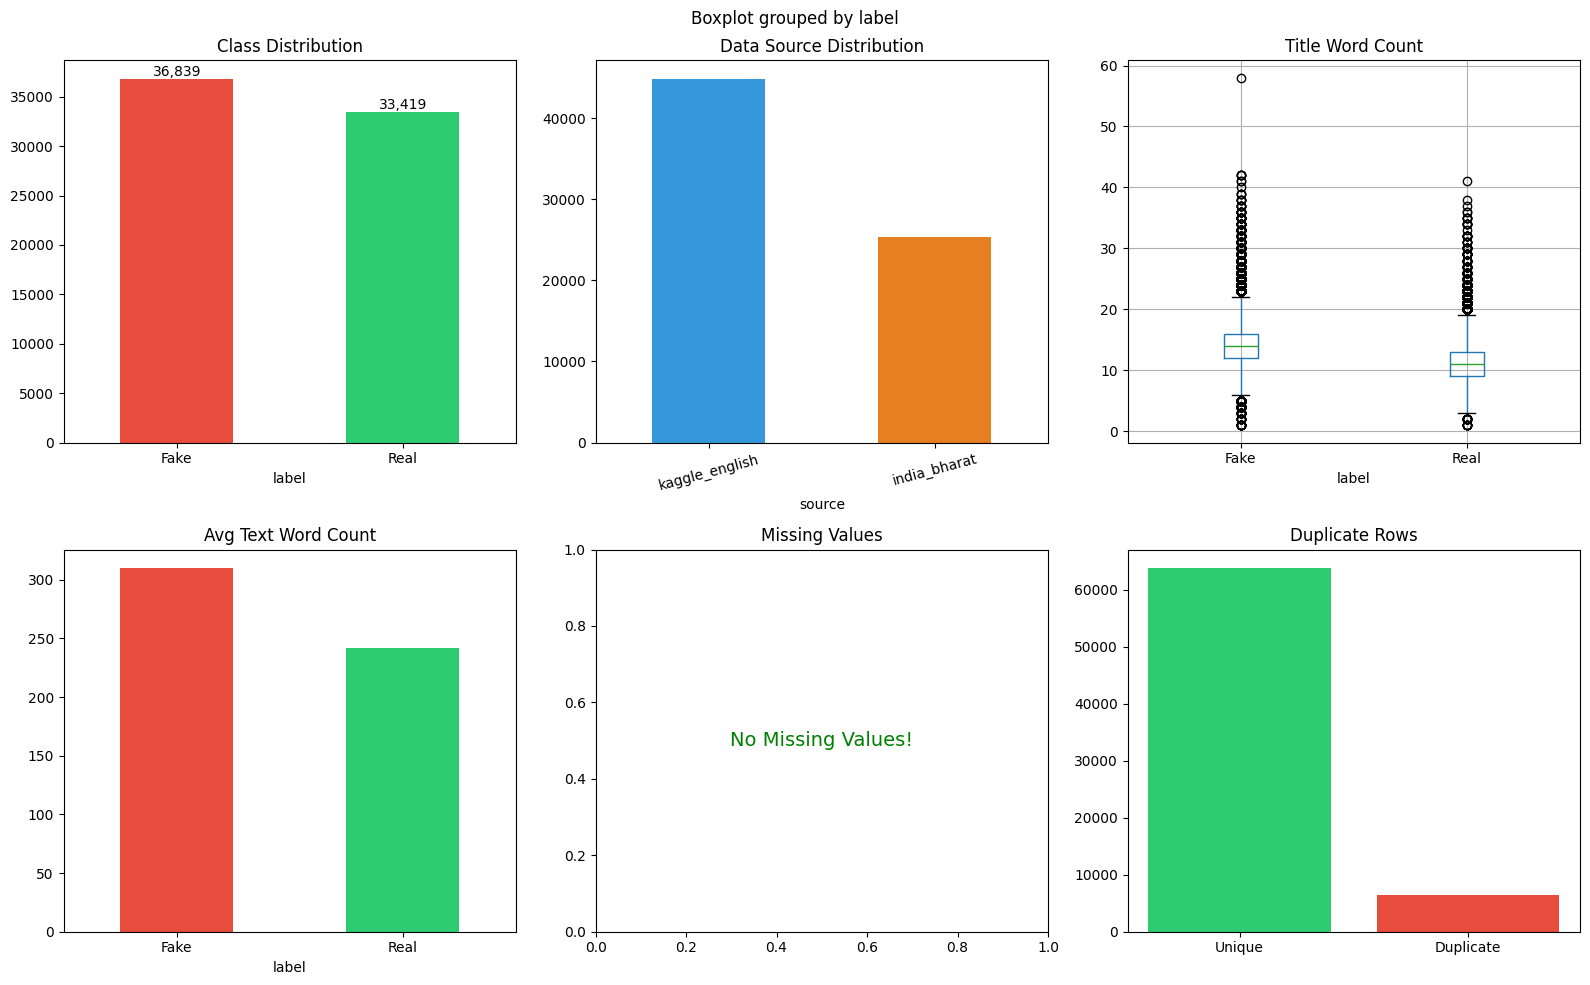


EDA Complete! ✅
Total samples: 70258
Duplicates found: 6392


In [ ]:
# STEP 4: EDA

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('VeriScan AI — Exploratory Data Analysis',
             fontsize=16, fontweight='bold')

# 1. Class distribution
df['label'].value_counts().plot(
    kind='bar', ax=axes[0,0],
    color=['#E74C3C','#2ECC71'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_xticklabels(['Fake','Real'], rotation=0)
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{int(p.get_height()):,}',
                       (p.get_x()+p.get_width()/2, p.get_height()),
                       ha='center', va='bottom')

# 2. Source distribution
df['source'].value_counts().plot(
    kind='bar', ax=axes[0,1],
    color=['#3498DB','#E67E22'])
axes[0,1].set_title('Data Source Distribution')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Title word count
df['title_word_count'] = df['title'].apply(
    lambda x: len(str(x).split()))
df.boxplot(column='title_word_count', by='label',
           ax=axes[0,2])
axes[0,2].set_title('Title Word Count: Fake vs Real')
axes[0,2].set_xticklabels(['Fake','Real'])
plt.sca(axes[0,2])
plt.title('Title Word Count')

# 4. Text word count
df['text_word_count'] = df['text'].apply(
    lambda x: len(str(x).split()))
df.groupby('label')['text_word_count'].mean().plot(
    kind='bar', ax=axes[1,0],
    color=['#E74C3C','#2ECC71'])
axes[1,0].set_title('Avg Text Word Count')
axes[1,0].set_xticklabels(['Fake','Real'], rotation=0)

# 5. Missing values
missing = df.isnull().sum()
missing[missing > 0].plot(
    kind='bar', ax=axes[1,1],
    color='#E74C3C') if missing.sum() > 0 else axes[1,1].text(
    0.5, 0.5, 'No Missing Values!',
    ha='center', va='center',
    transform=axes[1,1].transAxes,
    fontsize=14, color='green')
axes[1,1].set_title('Missing Values')

# 6. Duplicate check
dup_count = df.duplicated().sum()
axes[1,2].bar(['Unique', 'Duplicate'],
              [len(df)-dup_count, dup_count],
              color=['#2ECC71','#E74C3C'])
axes[1,2].set_title('Duplicate Rows')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nEDA Complete! ✅")
print(f"Total samples: {len(df)}")
print(f"Duplicates found: {dup_count}")

STEP 5 — Data Cleaning

In [ ]:
# STEP 5: DATA CLEANING

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Custom stopwords
custom_stops = {
    'said', 'would', 'also', 'one', 'two', 'new',
    'year', 'time', 'like', 'just', 'get', 'go',
    'could', 'make', 'say', 'will', 'may', 'us',
    'reuters', 'washington', 'trump', 'clinton',
    'image', 'photo', 'video', 'watch', 'read'
}
stop_words = stop_words.union(custom_stops)

def deep_clean(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [lemmatizer.lemmatize(w)
             for w in words
             if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Duplicates remove
df = df.drop_duplicates(subset=['title', 'text'])
df = df.dropna(subset=['title', 'text', 'label'])
df = df.reset_index(drop=True)

# Cleaning apply
print("Cleaning titles...")
df['clean_title'] = df['title'].apply(deep_clean)

print("Cleaning text...")
df['clean_text'] = df['text'].apply(deep_clean)

# Combined content
df['clean_content'] = df['clean_title'] + ' ' + df['clean_text']

# Empty rows remove
df = df[df['clean_content'].str.strip() != '']
df = df.reset_index(drop=True)

print(f"\nData Cleaning Complete! ✅")
print(f"Final dataset size: {df.shape}")
print(f"Duplicate Rows     : {df.duplicated().sum()}")
print(f"\nSample cleaned text:\n{df['clean_content'][0][:200]}")

Cleaning titles...
Cleaning text...

Data Cleaning Complete! ✅
Final dataset size: (63622, 9)
Duplicate Rows     : 0

Sample cleaned text:
leftist living change position turn obama declares warshut bordersno visa flashback see kudlow mock republican strong defense closing border interview gang eight member jeff flake raz year ago preside


STEP 6 — Feature Engineering

In [ ]:
# STEP 6: FEATURE ENGINEERING

def extract_features(df):
    # 1. Basic length features
    df['word_count'] = df['clean_content'].apply(
        lambda x: len(str(x).split()))
    df['char_count'] = df['clean_content'].apply(
        lambda x: len(str(x)))
    df['avg_word_length'] = df['clean_content'].apply(
        lambda x: np.mean([len(w) for w in str(x).split()])
        if len(str(x).split()) > 0 else 0)

    # 2. Punctuation features
    df['exclamation_count'] = df['text'].apply(
        lambda x: str(x).count('!'))
    df['question_count'] = df['text'].apply(
        lambda x: str(x).count('?'))

    # 3. CAPS words
    df['caps_word_count'] = df['text'].apply(
        lambda x: sum(1 for w in str(x).split()
                     if w.isupper() and len(w) > 2))

    # 4. Sensational words score
    sensational = [
        'breaking', 'urgent', 'shocking', 'exposed',
        'exclusive', 'viral', 'unbelievable', 'secret',
        'banned', 'bombshell', 'alert', 'warning'
    ]
    df['sensational_score'] = df['text'].apply(
        lambda x: sum(1 for w in sensational
                     if w in str(x).lower()))

    # 5. Credibility words score
    credibility = [
        'according to', 'reported', 'confirmed', 'official',
        'government', 'research', 'study', 'data', 'percent',
        'source', 'statement', 'announced', 'verified'
    ]
    df['credibility_score'] = df['text'].apply(
        lambda x: sum(1 for w in credibility
                     if w in str(x).lower()))

    # 6. Urgency phrases
    urgency = [
        'share this', 'forward to', 'please share',
        'must share', 'spread the word', 'kindly forward'
    ]
    df['urgency_score'] = df['text'].apply(
        lambda x: sum(1 for p in urgency
                     if p in str(x).lower()))

    # 7. Title features
    df['title_word_count'] = df['title'].apply(
        lambda x: len(str(x).split()))
    df['title_caps_ratio'] = df['title'].apply(
        lambda x: sum(1 for w in str(x).split()
                     if w.isupper()) /
        max(len(str(x).split()), 1))

    # 8. Unique word ratio
    df['unique_word_ratio'] = df['clean_content'].apply(
        lambda x: len(set(str(x).split())) /
        max(len(str(x).split()), 1))

    return df

df = extract_features(df)

# Feature comparison by label
feat_cols = ['word_count', 'exclamation_count',
             'caps_word_count', 'sensational_score',
             'credibility_score', 'urgency_score',
             'unique_word_ratio']

print("Feature Engineering Complete! ✅")
print("\nAverage feature values (0=Fake, 1=Real):")
print(df.groupby('label')[feat_cols].mean().round(3))
print(df.shape)

Feature Engineering Complete! ✅

Average feature values (0=Fake, 1=Real):
       word_count  exclamation_count  caps_word_count  sensational_score  \
label                                                                      
0         150.691              0.482            3.331              0.318   
1         138.342              0.050            3.207              0.311   

       credibility_score  urgency_score  unique_word_ratio  
label                                                       
0                  0.869          0.014              0.776  
1                  1.200          0.013              0.760  
(63622, 20)


STEP 7 — Feature Engineering Visualization

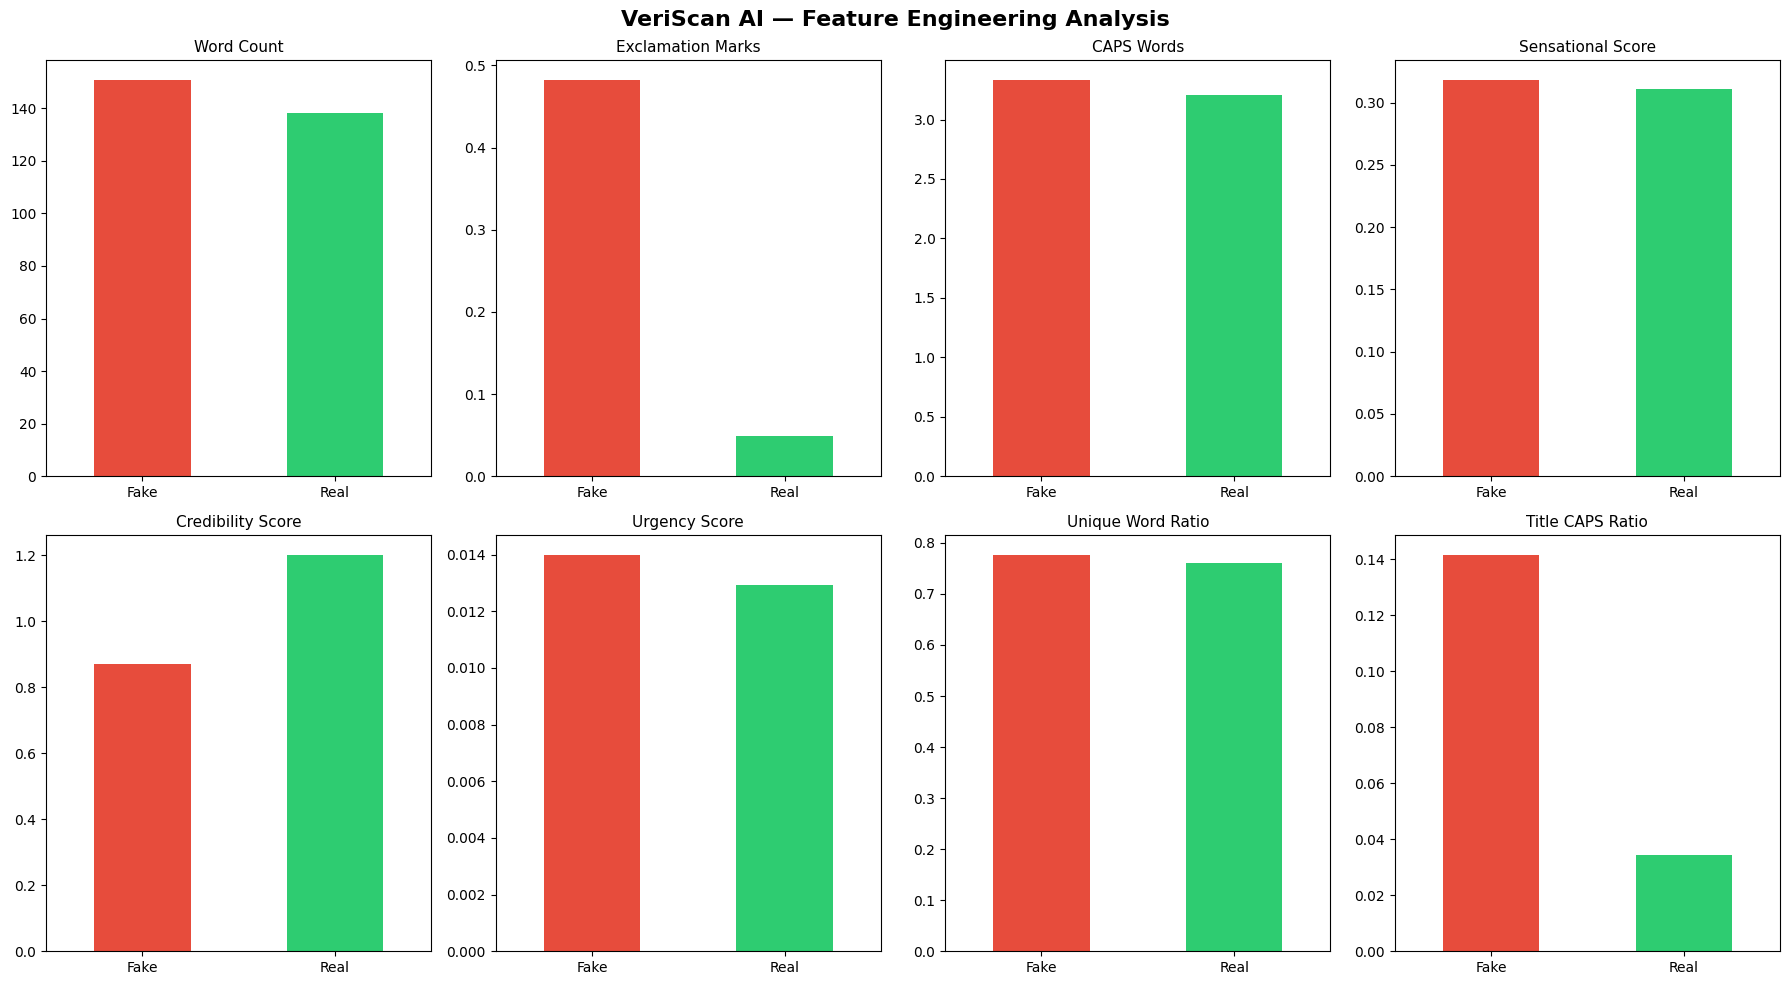

Feature visualization saved! ✅


In [ ]:
# STEP 7: FEATURE VISUALIZATION

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('VeriScan AI — Feature Engineering Analysis',
             fontsize=16, fontweight='bold')

features_to_plot = [
    ('word_count', 'Word Count'),
    ('exclamation_count', 'Exclamation Marks'),
    ('caps_word_count', 'CAPS Words'),
    ('sensational_score', 'Sensational Score'),
    ('credibility_score', 'Credibility Score'),
    ('urgency_score', 'Urgency Score'),
    ('unique_word_ratio', 'Unique Word Ratio'),
    ('title_caps_ratio', 'Title CAPS Ratio'),
]

for idx, (feat, title) in enumerate(features_to_plot):
    ax = axes[idx//4][idx%4]
    df.groupby('label')[feat].mean().plot(
        kind='bar', ax=ax,
        color=['#E74C3C','#2ECC71'])
    ax.set_title(title, fontsize=11)
    ax.set_xticklabels(['Fake','Real'], rotation=0)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature visualization saved! ✅")

STEP 8 — Feature Selection

Feature Selection Complete! ✅

Selected features (9):
  ✅ word_count
  ✅ char_count
  ✅ avg_word_length
  ✅ exclamation_count
  ✅ question_count
  ✅ credibility_score
  ✅ title_word_count
  ✅ title_caps_ratio
  ✅ unique_word_ratio

Dropped features (3):
  ❌ caps_word_count
  ❌ sensational_score
  ❌ urgency_score


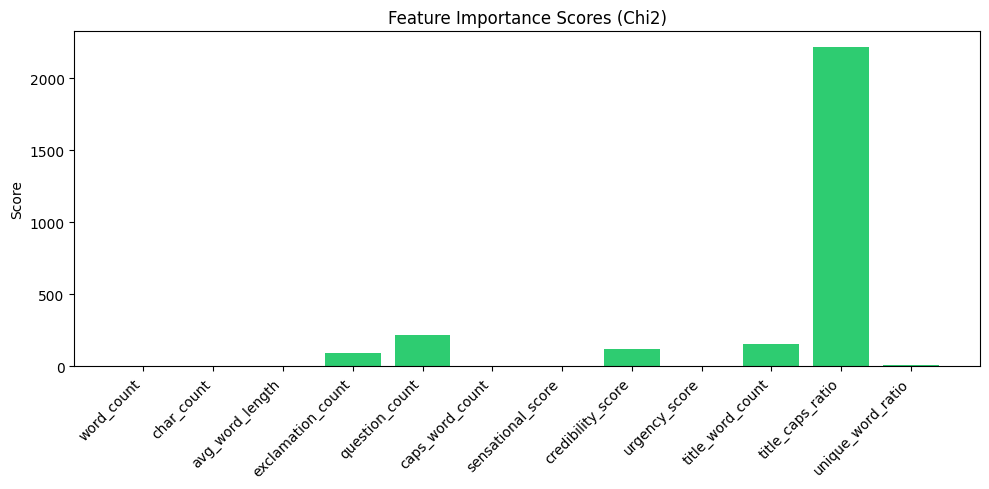

(63622, 20)


In [ ]:
# STEP 8: FEATURE SELECTION

custom_feat_cols = [
    'word_count', 'char_count', 'avg_word_length',
    'exclamation_count', 'question_count',
    'caps_word_count', 'sensational_score',
    'credibility_score', 'urgency_score',
    'title_word_count', 'title_caps_ratio',
    'unique_word_ratio'
]

X_custom_all = df[custom_feat_cols].values
y = df['label'].values

# Chi2 feature selection
from sklearn.preprocessing import MinMaxScaler
scaler_fs = MinMaxScaler()
X_scaled_fs = scaler_fs.fit_transform(X_custom_all)

selector = SelectKBest(chi2, k=9)
selector.fit(X_scaled_fs, y)

# Selected features
selected_mask = selector.get_support()
selected_features = [f for f, s in zip(
    custom_feat_cols, selected_mask) if s]
dropped_features = [f for f, s in zip(
    custom_feat_cols, selected_mask) if not s]

print("Feature Selection Complete! ✅")
print(f"\nSelected features ({len(selected_features)}):")
for f in selected_features:
    print(f"  ✅ {f}")
print(f"\nDropped features ({len(dropped_features)}):")
for f in dropped_features:
    print(f"  ❌ {f}")

# Feature importance plot
scores = selector.scores_
plt.figure(figsize=(10, 5))
plt.bar(custom_feat_cols, scores,
        color=['#2ECC71' if s else '#E74C3C'
               for s in selected_mask])
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance Scores (Chi2)')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig('feature_selection.png', dpi=150)
plt.show()
print(df.shape)

STEP 9 — Standardization / Normalization

In [ ]:
# STEP 9: STANDARDIZATION

X_custom = df[selected_features].values

# StandardScaler — mean=0, std=1
scaler = StandardScaler()
X_custom_scaled = scaler.fit_transform(X_custom)

print("Standardization Complete! ✅")
print(f"\nBefore scaling — mean: {X_custom.mean():.4f}")
print(f"After scaling  — mean: {X_custom_scaled.mean():.4f}")
print(f"\nBefore scaling — std: {X_custom.std():.4f}")
print(f"After scaling  — std: {X_custom_scaled.std():.4f}")

Standardization Complete! ✅

Before scaling — mean: 139.1723
After scaling  — mean: 0.0000

Before scaling — std: 532.5768
After scaling  — std: 1.0000


STEP 10 — TF-IDF + Train Test Split

In [ ]:
# STEP 10: TF-IDF + SPLIT

X_text = df['clean_content']
y = df['label'].values

# Train-Test Split
(X_train_text, X_test_text,
 X_train_custom, X_test_custom,
 y_train, y_test) = train_test_split(
    X_text, X_custom_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF — Bigrams
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# Combine TF-IDF + Custom Features
X_train_final = hstack([
    X_train_tfidf,
    sp.csr_matrix(X_train_custom)
])
X_test_final = hstack([
    X_test_tfidf,
    sp.csr_matrix(X_test_custom)
])

print("Data preparation complete! ✅")
print(f"Training samples : {X_train_final.shape[0]}")
print(f"Testing samples  : {X_test_final.shape[0]}")
print(f"Total features   : {X_train_final.shape[1]}")

Data preparation complete! ✅
Training samples : 50897
Testing samples  : 12725
Total features   : 10009


STEP 11 — Model Training + Evaluation

In [ ]:
# STEP 11: MODEL TRAINING

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0),
    'Passive Aggressive': PassiveAggressiveClassifier(
        C=0.5, max_iter=1000),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_final, y_train)
    pred = model.predict(X_test_final)
    acc  = accuracy_score(y_test, pred)

    # Cross validation
    cv_scores = cross_val_score(
        model, X_train_final, y_train,
        cv=5, scoring='accuracy')

    results[name] = {
        'model'    : model,
        'pred'     : pred,
        'accuracy' : acc,
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std()
    }
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  CV Score      : {cv_scores.mean():.4f} "
          f"(+/- {cv_scores.std():.4f})")

# Best model
best_name = max(results,
                key=lambda x: results[x]['accuracy'])
best_model = results[best_name]['model']
best_pred  = results[best_name]['pred']

print(f"\n🏆 Best Model: {best_name}")
print(f"   Accuracy: {results[best_name]['accuracy']:.4f}")


Training Logistic Regression...
  Test Accuracy : 0.8270
  CV Score      : 0.8271 (+/- 0.0036)

Training Passive Aggressive...
  Test Accuracy : 0.7697
  CV Score      : 0.8017 (+/- 0.0116)

Training Random Forest...
  Test Accuracy : 0.8384
  CV Score      : 0.8345 (+/- 0.0046)

🏆 Best Model: Random Forest
   Accuracy: 0.8384


STEP 12 — Evaluation Graphs

=== Classification Report ===
              precision    recall  f1-score   support

        Fake       0.99      0.63      0.77      5508
        Real       0.78      1.00      0.87      7217

    accuracy                           0.84     12725
   macro avg       0.89      0.81      0.82     12725
weighted avg       0.87      0.84      0.83     12725



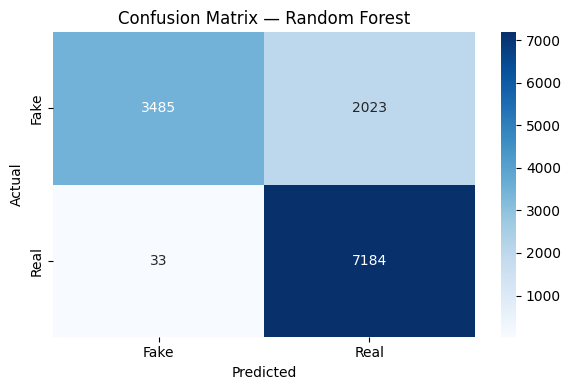

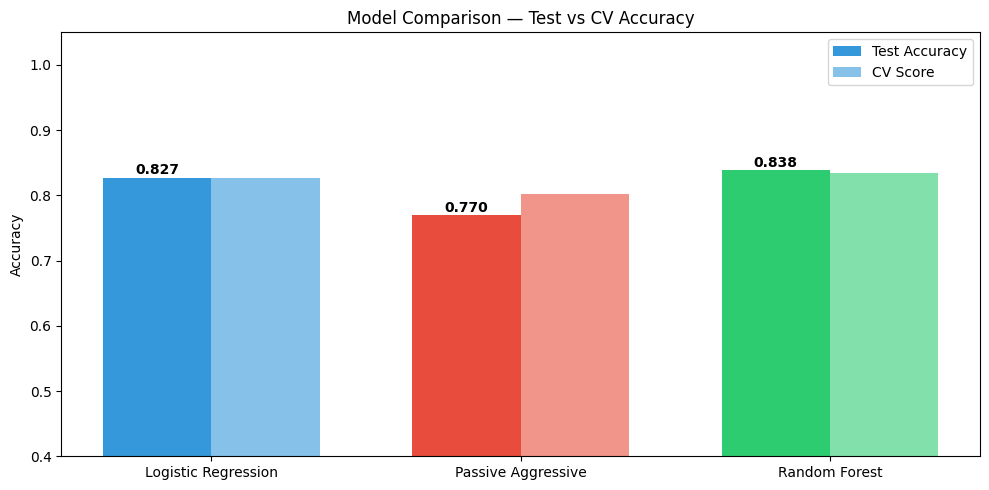

In [ ]:
# STEP 12: EVALUATION

print("=== Classification Report ===")
print(classification_report(
    y_test, best_pred,
    target_names=['Fake', 'Real']))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake','Real'],
            yticklabels=['Fake','Real'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Model Comparison
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
cvs   = [results[n]['cv_mean']  for n in names]

x = np.arange(len(names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accs, width,
               label='Test Accuracy',
               color=['#3498DB','#E74C3C','#2ECC71'])
bars2 = ax.bar(x + width/2, cvs, width,
               label='CV Score',
               color=['#85C1E9','#F1948A','#82E0AA'])

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('Model Comparison — Test vs CV Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0.4, 1.05)
ax.legend()
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

STEP 13 — LSTM Deep Learning

In [ ]:
# STEP 13: LSTM
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    Bidirectional, GlobalMaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping

X_seq = df['clean_content'].values
y_seq = df['label'].values

X_tr_seq, X_te_seq, y_tr_seq, y_te_seq = train_test_split(
    X_seq, y_seq,
    test_size=0.2, random_state=42, stratify=y_seq)

tok = Tokenizer(num_words=10000, oov_token='<OOV>')
tok.fit_on_texts(X_tr_seq)

X_tr_pad = pad_sequences(
    tok.texts_to_sequences(X_tr_seq),
    maxlen=300, padding='post', truncating='post')
X_te_pad = pad_sequences(
    tok.texts_to_sequences(X_te_seq),
    maxlen=300, padding='post', truncating='post')

lstm_model = Sequential([
    Embedding(10000, 64, input_length=300),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

lstm_model.summary()

history = lstm_model.fit(
    X_tr_pad, y_tr_seq,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True)],
    verbose=1)

_, lstm_acc = lstm_model.evaluate(
    X_te_pad, y_te_seq, verbose=0)
print(f"\nLSTM Test Accuracy: {lstm_acc:.4f}")

# Final comparison
print("\n=== FINAL MODEL COMPARISON ===")
for name in results:
    print(f"{name:25s}: {results[name]['accuracy']:.4f}")
print(f"{'LSTM (Bidirectional)':25s}: {lstm_acc:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 212s 291ms/step - accuracy: 0.7876 - loss: 0.3882 - val_accuracy: 0.8291 - val_loss: 0.3040
Epoch 2/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 244s 267ms/step - accuracy: 0.8401 - loss: 0.2858 - val_accuracy: 0.8295 - val_loss: 0.2976
Epoch 3/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 205s 271ms/step - accuracy: 0.8541 - loss: 0.2628 - val_accuracy: 0.8275 - val_loss: 0.3240
Epoch 4/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 200s 280ms/step - accuracy: 0.8657 - loss: 0.2455 - val_accuracy: 0.8271 - val_loss: 0.3390

LSTM Test Accuracy: 0.8345

=== FINAL MODEL COMPARISON ===
Logistic Regression      : 0.8270
Passive Aggressive       : 0.7697
Random Forest            : 0.8384
LSTM (Bidirectional)     : 0.8345


STEP 14 — Model Save

In [ ]:
# STEP 14: SAVE MODELS
import pickle

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

print("All models saved! ✅")
print(f"Best model: {best_name}")

All models saved! ✅
Best model: Random Forest
